# Profil Dataset PPE

Notebook ini untuk memeriksa dataset PPE sebelum training.

**Dataset:** [Personal Protective Equipment - Combined Model v8](https://universe.roboflow.com/roboflow-universe-projects/personal-protective-equipment-combined-model/dataset/8) (Roboflow, CC BY 4.0)

**14 kelas:**

| ID | Nama | Kategori |
|---|---|---|
| 0 | Fall-Detected | Kejadian |
| 1 | Gloves | APD |
| 2 | Goggles | APD |
| 3 | Hardhat | APD |
| 4 | Ladder | Objek |
| 5 | Mask | APD |
| 6 | NO-Gloves | Pelanggaran |
| 7 | NO-Goggles | Pelanggaran |
| 8 | NO-Hardhat | Pelanggaran |
| 9 | NO-Mask | Pelanggaran |
| 10 | NO-Safety Vest | Pelanggaran |
| 11 | Person | Orang |
| 12 | Safety Cone | Objek |
| 13 | Safety Vest | APD |

## Alur

1. Setup path
2. Distribusi kelas per split
3. Cek imbalance
4. Sample gambar
5. Kesimpulan

## Setup

In [1]:
%matplotlib inline

from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

DATASET_DIR = RESEARCH_DIR / "datasets" / "raw" / "ppe"
DATA_YAML   = DATASET_DIR / "data.yaml"

ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "ppe_compliance"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Nggak ketemu: {DATA_YAML}")

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
CLASS_NAMES: list[str] = cfg["names"]
NC = cfg["nc"]

print(f"Dataset: {DATASET_DIR}")
print(f"Jumlah kelas: {NC}")
print(f"Kelas: {CLASS_NAMES}")

Dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\ppe
Jumlah kelas: 14
Kelas: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


## Distribusi Kelas

Hitung jumlah instance per kelas per split (train/valid/test). Penting untuk deteksi imbalance sebelum training.

In [2]:
def count_class_distribution(split: str) -> dict[int, int]:
    counts: dict[int, int] = {i: 0 for i in range(NC)}
    labels_dir = DATASET_DIR / split / "labels"
    if not labels_dir.exists():
        print(f"Warning: {labels_dir} nggak ada")
        return counts
    for lbl in labels_dir.glob("*.txt"):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
    return counts


splits = ["train", "valid", "test"]
dist = {s: count_class_distribution(s) for s in splits}

dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = [CLASS_NAMES[i] for i in dist_df.index]
dist_df["total"] = dist_df.sum(axis=1)
dist_df = dist_df.sort_values("total", ascending=False)

print("Distribusi per kelas per split:")
print(dist_df.to_string())
print()
print(f"Total instance: {dist_df['total'].sum():,}")
print(f"Total gambar: train={len(list((DATASET_DIR / 'train' / 'images').glob('*')))}, "
      f"valid={len(list((DATASET_DIR / 'valid' / 'images').glob('*')))}, "
      f"test={len(list((DATASET_DIR / 'test' / 'images').glob('*')))}")

Distribusi per kelas per split:
                train  valid  test  total
Hardhat         28996   8952  4480  42428
Safety Cone      9843   3016  1597  14456
NO-Hardhat       9691   2208  1038  12937
Safety Vest      4494   1287   662   6443
NO-Gloves        4280   1258   597   6135
Gloves           3381    858   430   4669
Fall-Detected    3149    899   450   4498
Goggles          2959    827   402   4188
NO-Goggles       2817    859   416   4092
Mask             1961    554   329   2844
NO-Mask          1577    505   218   2300
NO-Safety Vest   1432    359   226   2017
Person           1034    276   138   1448
Ladder            734    201   103   1038

Total instance: 109,493
Total gambar: train=30756, valid=8810, test=4423


### Visualisasi Distribusi

Bar chart horizontal supaya nama kelas terbaca jelas.

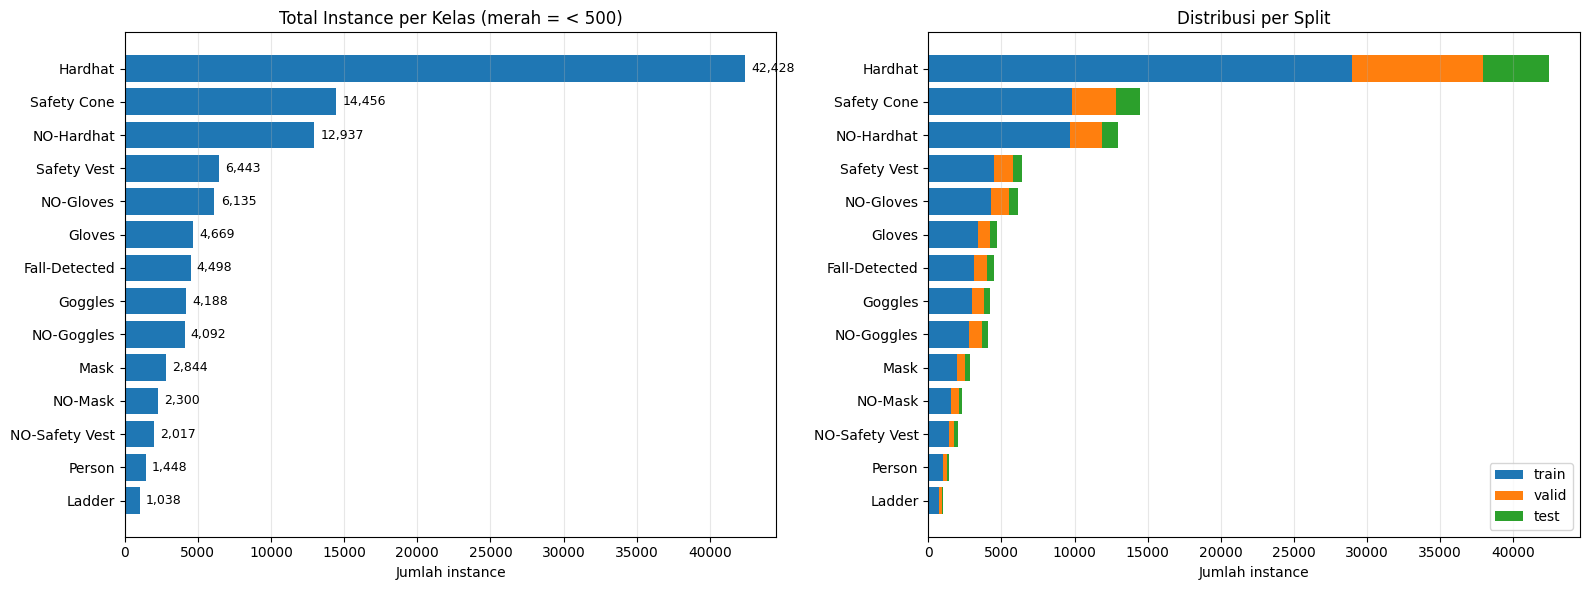

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: total per kelas
plot_df = dist_df["total"].sort_values()
colors = ["#d62728" if v < 500 else "#1f77b4" for v in plot_df.values]
bars = axes[0].barh(plot_df.index, plot_df.values, color=colors)
for bar, val in zip(bars, plot_df.values):
    axes[0].text(val + plot_df.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)
axes[0].set_xlabel("Jumlah instance")
axes[0].set_title("Total Instance per Kelas (merah = < 500)")
axes[0].grid(axis="x", alpha=0.3)

# Stacked bar: per split
split_df = dist_df[splits].loc[plot_df.index]
left = [0] * len(split_df)
split_colors = {"train": "#1f77b4", "valid": "#ff7f0e", "test": "#2ca02c"}
for s in splits:
    axes[1].barh(split_df.index, split_df[s], left=left,
                 label=s, color=split_colors[s])
    left = [l + v for l, v in zip(left, split_df[s])]
axes[1].set_xlabel("Jumlah instance")
axes[1].set_title("Distribusi per Split")
axes[1].legend()
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis Imbalance

Cek rasio kelas terbesar vs terkecil. Kalau ada kelas < 500 instance, perlu strategi khusus saat training.

In [4]:
totals = dist_df["total"]
max_cls = totals.idxmax()
min_cls = totals.idxmin()
ratio = totals.max() / totals.min() if totals.min() > 0 else float("inf")

print(f"Kelas terbanyak : {max_cls} ({totals.max():,})")
print(f"Kelas tersedikit: {min_cls} ({totals.min():,})")
print(f"Rasio max/min   : {ratio:.1f}x")
print()

low_classes = totals[totals < 500]
if len(low_classes) > 0:
    print(f"Kelas dengan < 500 instance ({len(low_classes)} kelas):")
    for name, count in low_classes.sort_values().items():
        print(f"  - {name}: {count:,}")
    print()
    print("Saran: pertimbangkan oversample atau class-weighted loss saat training.")
else:
    print("Semua kelas punya >= 500 instance. Imbalance ringan.")

print()
mid_classes = totals[(totals >= 500) & (totals < 2000)]
if len(mid_classes) > 0:
    print(f"Kelas menengah (500-2000 instance, {len(mid_classes)} kelas):")
    for name, count in mid_classes.sort_values().items():
        print(f"  - {name}: {count:,}")

Kelas terbanyak : Hardhat (42,428)
Kelas tersedikit: Ladder (1,038)
Rasio max/min   : 40.9x

Semua kelas punya >= 500 instance. Imbalance ringan.

Kelas menengah (500-2000 instance, 2 kelas):
  - Ladder: 1,038
  - Person: 1,448


### Proporsi Kelas (Pie Chart)

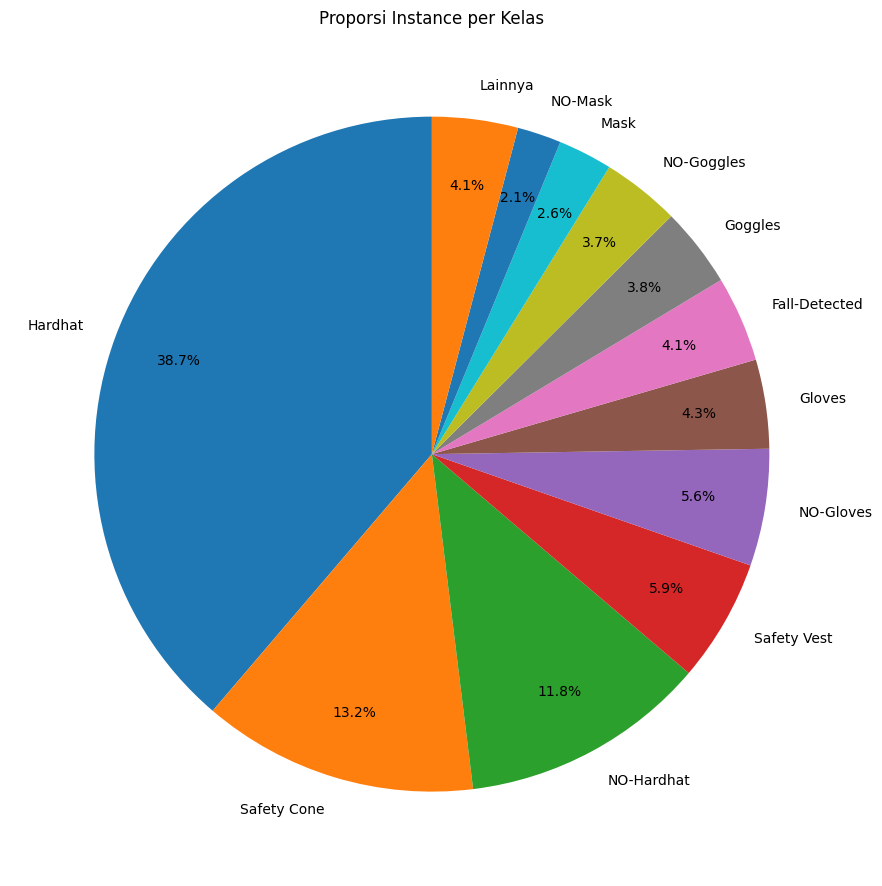

In [5]:
fig, ax = plt.subplots(figsize=(9, 9))
sorted_totals = totals.sort_values(ascending=False)
threshold = sorted_totals.sum() * 0.02
main = sorted_totals[sorted_totals >= threshold]
other = sorted_totals[sorted_totals < threshold]
if len(other) > 0:
    main = pd.concat([main, pd.Series({"Lainnya": other.sum()})])

ax.pie(main, labels=main.index, autopct="%1.1f%%", startangle=90, pctdistance=0.8)
ax.set_title("Proporsi Instance per Kelas")
plt.tight_layout()
plt.show()

## Ukuran Bbox

Distribusi ukuran bounding box (lebar × tinggi relatif terhadap gambar). Berguna untuk menentukan `imgsz` saat training — kalau banyak bbox kecil, mungkin perlu resolusi lebih tinggi.

Statistik bbox (relatif, train split):
            width      height        area
count  76348.0000  76348.0000  76348.0000
mean       0.1304      0.1692      0.0438
std        0.1576      0.1653      0.1009
min        0.0008      0.0016      0.0000
25%        0.0469      0.0609      0.0031
50%        0.0742      0.1109      0.0082
75%        0.1344      0.2055      0.0257
max        1.0000      1.0000      1.0000


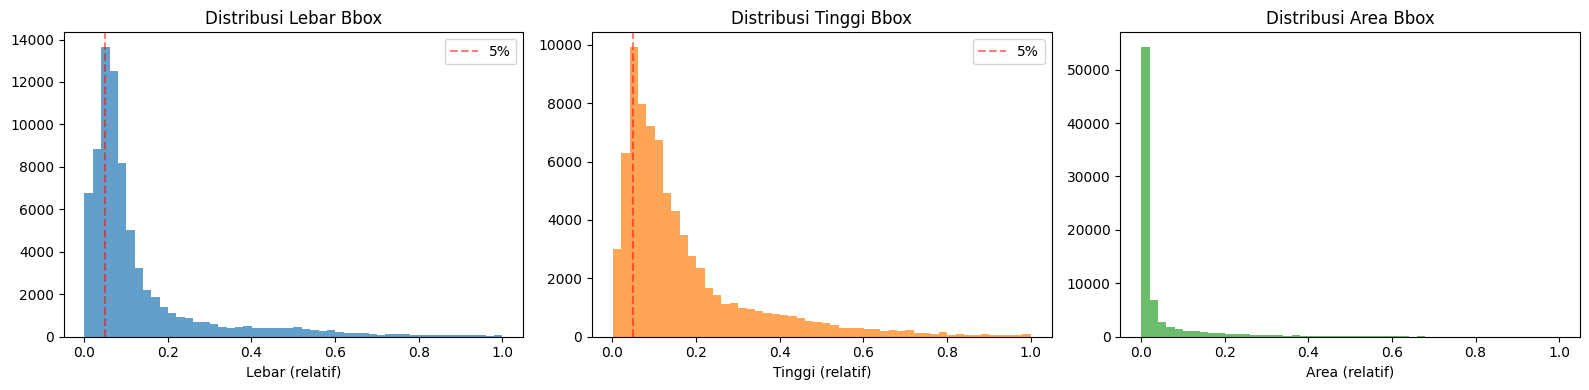


Bbox kecil (area < 1%): 55.3% dari total
Banyak objek kecil. Pertimbangkan imgsz=1280 saat training.


In [6]:
bbox_data = []
labels_dir = DATASET_DIR / "train" / "labels"
for lbl in labels_dir.glob("*.txt"):
    for line in lbl.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        cls = int(parts[0])
        w, h = float(parts[3]), float(parts[4])
        bbox_data.append({"class": CLASS_NAMES[cls], "width": w, "height": h})

bbox_df = pd.DataFrame(bbox_data)
bbox_df["area"] = bbox_df["width"] * bbox_df["height"]

print("Statistik bbox (relatif, train split):")
print(bbox_df[["width", "height", "area"]].describe().round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(bbox_df["width"], bins=50, color="#1f77b4", alpha=0.7)
axes[0].set_title("Distribusi Lebar Bbox")
axes[0].set_xlabel("Lebar (relatif)")
axes[0].axvline(0.05, color="red", linestyle="--", alpha=0.5, label="5%")
axes[0].legend()

axes[1].hist(bbox_df["height"], bins=50, color="#ff7f0e", alpha=0.7)
axes[1].set_title("Distribusi Tinggi Bbox")
axes[1].set_xlabel("Tinggi (relatif)")
axes[1].axvline(0.05, color="red", linestyle="--", alpha=0.5, label="5%")
axes[1].legend()

axes[2].hist(bbox_df["area"], bins=50, color="#2ca02c", alpha=0.7)
axes[2].set_title("Distribusi Area Bbox")
axes[2].set_xlabel("Area (relatif)")

plt.tight_layout()
plt.show()

small_ratio = (bbox_df["area"] < 0.01).mean() * 100
print(f"\nBbox kecil (area < 1%): {small_ratio:.1f}% dari total")
if small_ratio > 30:
    print("Banyak objek kecil. Pertimbangkan imgsz=1280 saat training.")

## Sample Gambar

Tampilkan beberapa gambar random dari train split beserta bounding box-nya. Untuk sanity check kualitas label.

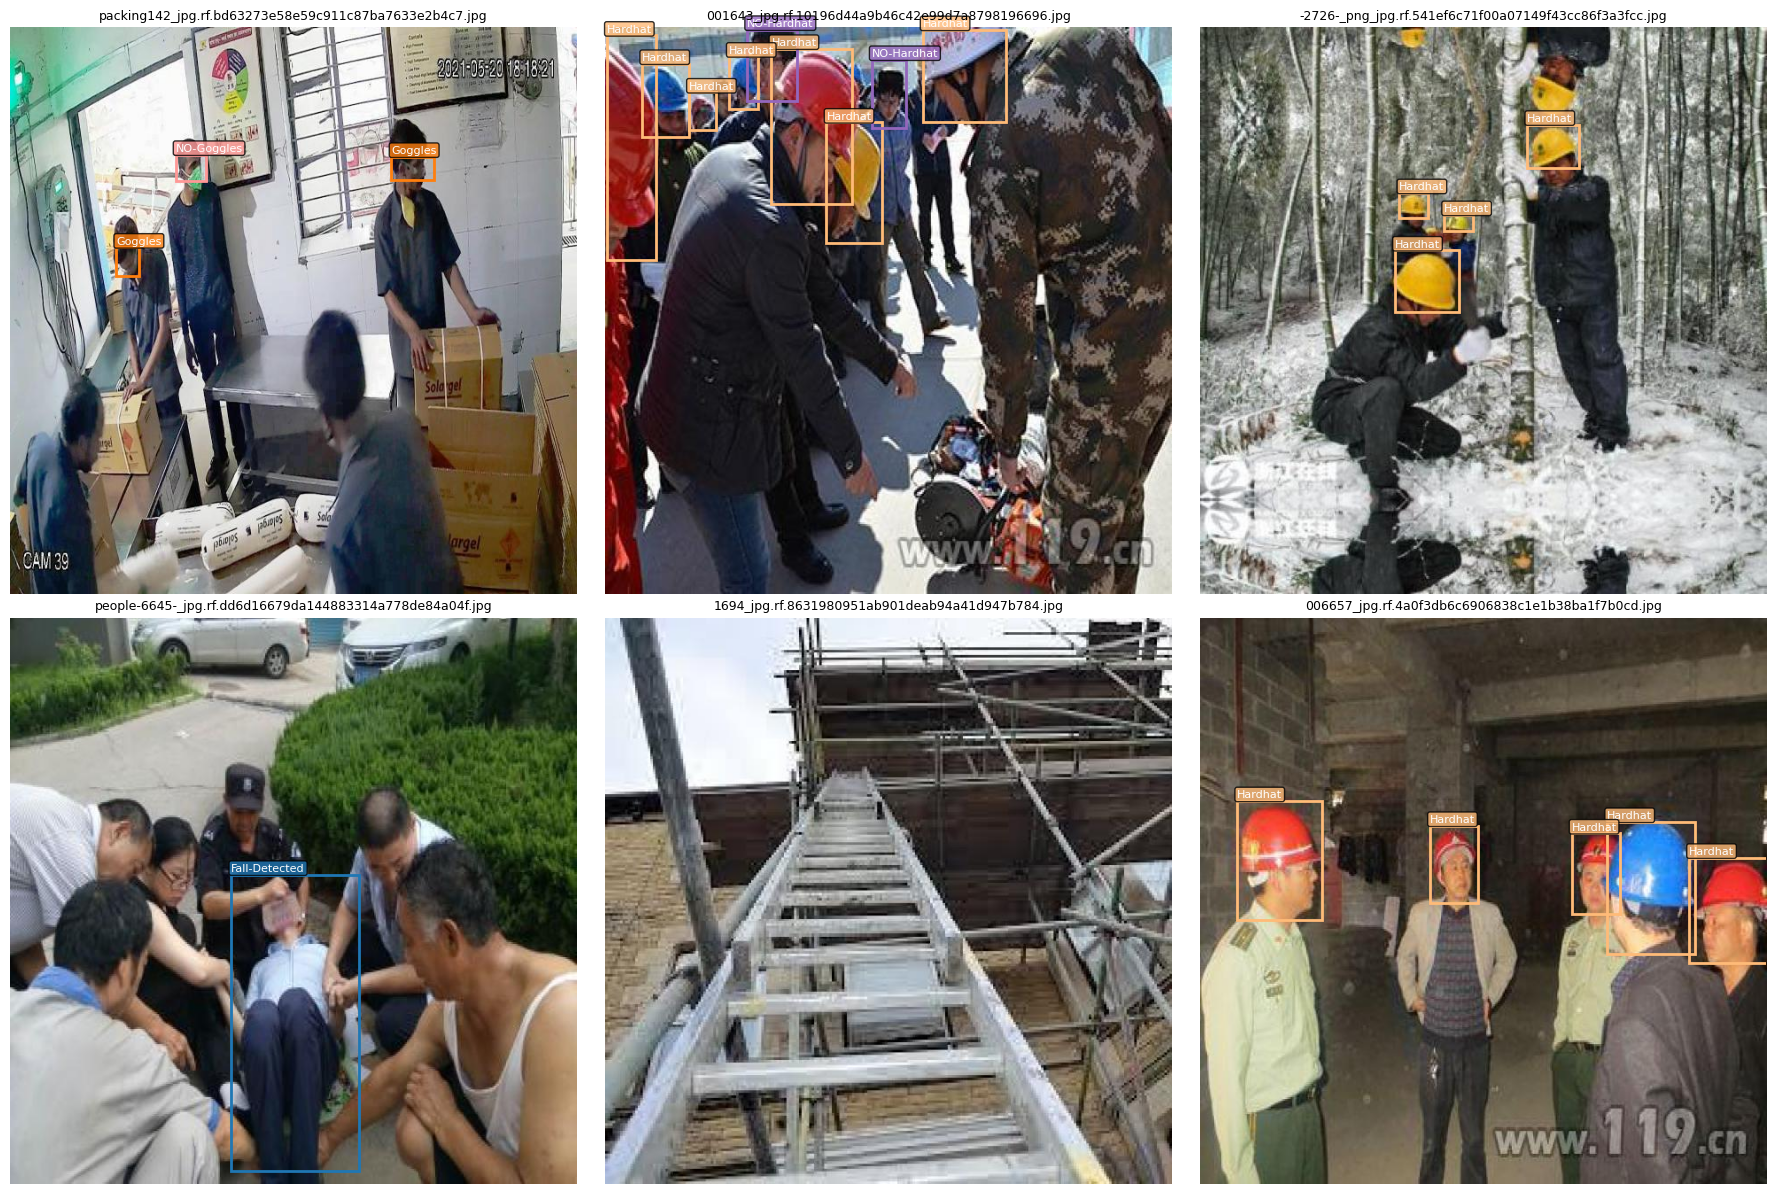

In [7]:
import matplotlib.patches as patches

N_SAMPLES = 6
images_dir = DATASET_DIR / "train" / "images"
all_images = sorted(images_dir.glob("*"))
samples = random.Random(SEED).sample(all_images, min(N_SAMPLES, len(all_images)))

COLORS = plt.cm.tab20.colors

cols = 3
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(18, 6 * rows_n))
axes = axes.flatten()

for ax, img_path in zip(axes, samples):
    img = Image.open(img_path)
    w_img, h_img = img.size
    ax.imshow(img)

    label_path = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            cls = int(parts[0])
            cx, cy, bw, bh = [float(p) for p in parts[1:5]]
            x1 = (cx - bw / 2) * w_img
            y1 = (cy - bh / 2) * h_img
            rect = patches.Rectangle(
                (x1, y1), bw * w_img, bh * h_img,
                linewidth=2, edgecolor=COLORS[cls % len(COLORS)], facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, CLASS_NAMES[cls], fontsize=8, color="white",
                    bbox=dict(boxstyle="round,pad=0.2", fc=COLORS[cls % len(COLORS)], alpha=0.8))

    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Simpan Ringkasan

Export distribusi ke CSV di `artifacts/ppe_compliance/` supaya bisa dipakai di notebook berikutnya.

In [8]:
out_path = ARTIFACTS_DIR / "class_distribution.csv"
dist_df.to_csv(out_path)
print(f"Tersimpan: {out_path}")

Tersimpan: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\artifacts\ppe_compliance\class_distribution.csv


## Kesimpulan

Isi bagian ini setelah notebook dijalankan.

**Checklist sebelum lanjut ke `02_train.ipynb`:**

- [ ] Semua 14 kelas punya label yang masuk akal (cek sample gambar)
- [ ] Identifikasi kelas yang imbalanced (< 500 instance)
- [ ] Tentukan `imgsz` — 640 default, 1280 kalau banyak objek kecil
- [ ] Tentukan strategi imbalance — default training dulu, augmentasi kalau perlu